In [3]:
!pip install timm einops opencv-python scikit-image -q


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import os
import subprocess
import urllib.request
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from skimage.metrics import peak_signal_noise_ratio, structural_similarity

In [13]:
DRIVE_URL = '/content/drive/MyDrive/VISION-4/RETO4'
LOCAL_PATH = os.getcwd()

In [14]:
def detect_environment():
    try:
        ipython_env = str(get_ipython())

        if 'google.colab' in ipython_env:
            return "Google Colab"
        elif 'zmqshell' in ipython_env:
            return "Jupyter Notebook Local"
        else:
            return "Terminal interactiva de Python"
    except NameError:
        return "Script de Python estándar (.py)"


print(f"Entorno detectado: {detect_environment()}")

Entorno detectado: Jupyter Notebook Local


In [15]:
if detect_environment() != "Google Colab":
    BASE = LOCAL_PATH
else:
    BASE = DRIVE_URL
    from google.colab import drive

    drive.mount('/content/drive')

In [16]:
DATASET_DIR = os.path.join(BASE, "dataset")

NOISY_PATH = os.path.join(DATASET_DIR, "noisy")
GTRUTH_PATH = os.path.join(DATASET_DIR, "gtruth")

OUTPUT_PATH = os.path.join(BASE, "evidence")
RESTORED_PATH = os.path.join(OUTPUT_PATH, "restored_tiff")

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(RESTORED_PATH, exist_ok=True)

print("Noisy:", NOISY_PATH)
print("Ground Truth:", GTRUTH_PATH)
print("Evidencias:", OUTPUT_PATH)

print("Existe noisy:", os.path.exists(NOISY_PATH))
print("Existe gtruth:", os.path.exists(GTRUTH_PATH))

Noisy: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\excercise_four\dataset\noisy
Ground Truth: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\excercise_four\dataset\gtruth
Evidencias: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\excercise_four\evidence
Existe noisy: True
Existe gtruth: True


In [17]:
SWINIR_DIR = os.path.join(LOCAL_PATH, "SwinIR")

if not os.path.exists(SWINIR_DIR):
    print(f"Clonando el repositorio SwinIR en: {SWINIR_DIR}")
    subprocess.run(
        ["git", "clone", "https://github.com/JingyunLiang/SwinIR.git", SWINIR_DIR],
        check=True
    )
    print("✓ Repositorio clonado.")
else:
    print("✓ El repositorio SwinIR ya está clonado.")

Clonando el repositorio SwinIR en: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\excercise_four\SwinIR
✓ Repositorio clonado.


In [18]:
MODEL_DIR = os.path.join(SWINIR_DIR, "model_zoo", "swinir")
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_FILENAME = "004_grayDN_DFWB_s128w8_SwinIR-M_noise25.pth"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_FILENAME)
MODEL_URL = f"https://github.com/JingyunLiang/SwinIR/releases/download/v0.0/{MODEL_FILENAME}"

if not os.path.exists(MODEL_PATH):
    print(f"Descargando pesos preentrenados en: {MODEL_PATH}...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("✓ Descarga de pesos completada.")
else:
    print("✓ Los pesos preentrenados ya existen localmente.")

Descargando pesos preentrenados en: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\excercise_four\SwinIR\model_zoo\swinir\004_grayDN_DFWB_s128w8_SwinIR-M_noise25.pth...
✓ Descarga de pesos completada.


In [19]:
if SWINIR_DIR not in sys.path:
    sys.path.append(SWINIR_DIR)

try:
    from models.network_swinir import SwinIR as net
    print("✓ Arquitectura SwinIR importada correctamente.")
except ImportError as e:
    print(f"Error al importar SwinIR: {e}")

C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Arquitectura SwinIR importada correctamente.


C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cpu


In [21]:
model = net(
    upscale=1,
    in_chans=1,
    img_size=128,
    window_size=8,
    img_range=1.0,
    depths=[6, 6, 6, 6, 6, 6],
    embed_dim=180,
    num_heads=[6, 6, 6, 6, 6, 6],
    mlp_ratio=2,
    upsampler="",
    resi_connection="1conv"
)

pretrained_model = torch.load(MODEL_PATH, map_location=device)

if "params" in pretrained_model:
    model.load_state_dict(pretrained_model["params"], strict=True)
elif "params_ema" in pretrained_model:
    model.load_state_dict(pretrained_model["params_ema"], strict=True)
else:
    model.load_state_dict(pretrained_model, strict=True)

model.eval()
model = model.to(device)

print("SwinIR de denoising cargado correctamente")

C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideFour\.venv\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


SwinIR de denoising cargado correctamente


In [22]:
def listar_tiff(folder):
    return sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".tiff", ".tif"))
    ])


noisy_files = listar_tiff(NOISY_PATH)
gtruth_files = listar_tiff(GTRUTH_PATH)

common_files = sorted(list(set(noisy_files).intersection(set(gtruth_files))))

print("Archivos noisy:", len(noisy_files))
print("Archivos gtruth:", len(gtruth_files))
print("Pares encontrados:", len(common_files))

if len(common_files) == 0:
    raise ValueError("No hay archivos .tiff/.tif con el mismo nombre en noisy y gtruth.")

Archivos noisy: 16
Archivos gtruth: 16
Pares encontrados: 16


In [23]:
IMG_SIZE = 512


def read_tiff_gray(path, size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"No se pudo leer la imagen: {path}")

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

    if img.dtype == np.uint16:
        img = img.astype(np.float32) / 65535.0
    elif img.dtype == np.uint8:
        img = img.astype(np.float32) / 255.0
    else:
        img = img.astype(np.float32)
        if img.max() > 1:
            img = img / 65535.0 if img.max() > 255 else img / 255.0

    img = np.clip(img, 0, 1)

    return img


def gray_to_tensor(img_gray):
    tensor = torch.from_numpy(img_gray).float()
    tensor = tensor.unsqueeze(0).unsqueeze(0)
    return tensor.to(device)


def tensor_to_gray(output_tensor):
    output = output_tensor.detach().float().cpu().clamp(0, 1).numpy()
    gray = output[0, 0]
    return gray.astype(np.float32)

In [24]:
def restaurar_con_swinir(noisy_gray):
    input_tensor = gray_to_tensor(noisy_gray)

    with torch.no_grad():
        output = model(input_tensor)

    restored_gray = tensor_to_gray(output)

    return restored_gray

In [25]:
def calcular_psnr(gt, pred):
    return peak_signal_noise_ratio(gt, pred, data_range=1.0)


def calcular_ssim(gt, pred):
    return structural_similarity(gt, pred, data_range=1.0)


def calcular_enl(img):
    img = img.astype(np.float32)
    mean = np.mean(img)
    var = np.var(img)

    if var == 0:
        return np.nan

    return (mean ** 2) / var

In [ ]:
rows = []
visual_examples = []

# Puedes limitar para prueba rápida.
# Para procesar todo, deja MAX_IMAGES = None
MAX_IMAGES = None

files_to_process = common_files if MAX_IMAGES is None else common_files[:MAX_IMAGES]

for i, filename in enumerate(files_to_process):
    noisy_path = os.path.join(NOISY_PATH, filename)
    gtruth_path = os.path.join(GTRUTH_PATH, filename)

    noisy_img = read_tiff_gray(noisy_path)
    gtruth_img = read_tiff_gray(gtruth_path)

    restored_img = restaurar_con_swinir(noisy_img)

    if restored_img.shape != gtruth_img.shape:
        restored_img = cv2.resize(
            restored_img,
            (gtruth_img.shape[1], gtruth_img.shape[0]),
            interpolation=cv2.INTER_AREA
        )

    restored_img = np.clip(restored_img, 0, 1)
    psnr_noisy = calcular_psnr(gtruth_img, noisy_img)
    psnr_restored = calcular_psnr(gtruth_img, restored_img)

    ssim_noisy = calcular_ssim(gtruth_img, noisy_img)
    ssim_restored = calcular_ssim(gtruth_img, restored_img)

    enl_noisy = calcular_enl(noisy_img)
    enl_restored = calcular_enl(restored_img)
    enl_gtruth = calcular_enl(gtruth_img)

    rows.append({
        "archivo": filename,
        "PSNR_noisy": psnr_noisy,
        "PSNR_swinir": psnr_restored,
        "SSIM_noisy": ssim_noisy,
        "SSIM_swinir": ssim_restored,
        "ENL_noisy": enl_noisy,
        "ENL_swinir": enl_restored,
        "ENL_gtruth": enl_gtruth
    })

    restored_uint16 = np.clip(restored_img * 65535, 0, 65535).astype(np.uint16)
    output_file = os.path.join(RESTORED_PATH, filename)
    cv2.imwrite(output_file, restored_uint16)

    if len(visual_examples) < 5:
        visual_examples.append((filename, noisy_img, gtruth_img, restored_img))

    print(f"[{i + 1}/{len(files_to_process)}] Procesado: {filename}")

df_metrics = pd.DataFrame(rows)
df_metrics.head()

In [15]:
summary_metrics = df_metrics.drop(columns=["archivo"]).mean().to_frame(name="promedio")
summary_metrics

,promedio
PSNR_noisy,30.574867
PSNR_swinir,31.432293
SSIM_noisy,0.890217
SSIM_swinir,0.926470
ENL_noisy,25.576889
ENL_swinir,339.475494
ENL_gtruth,91.870087


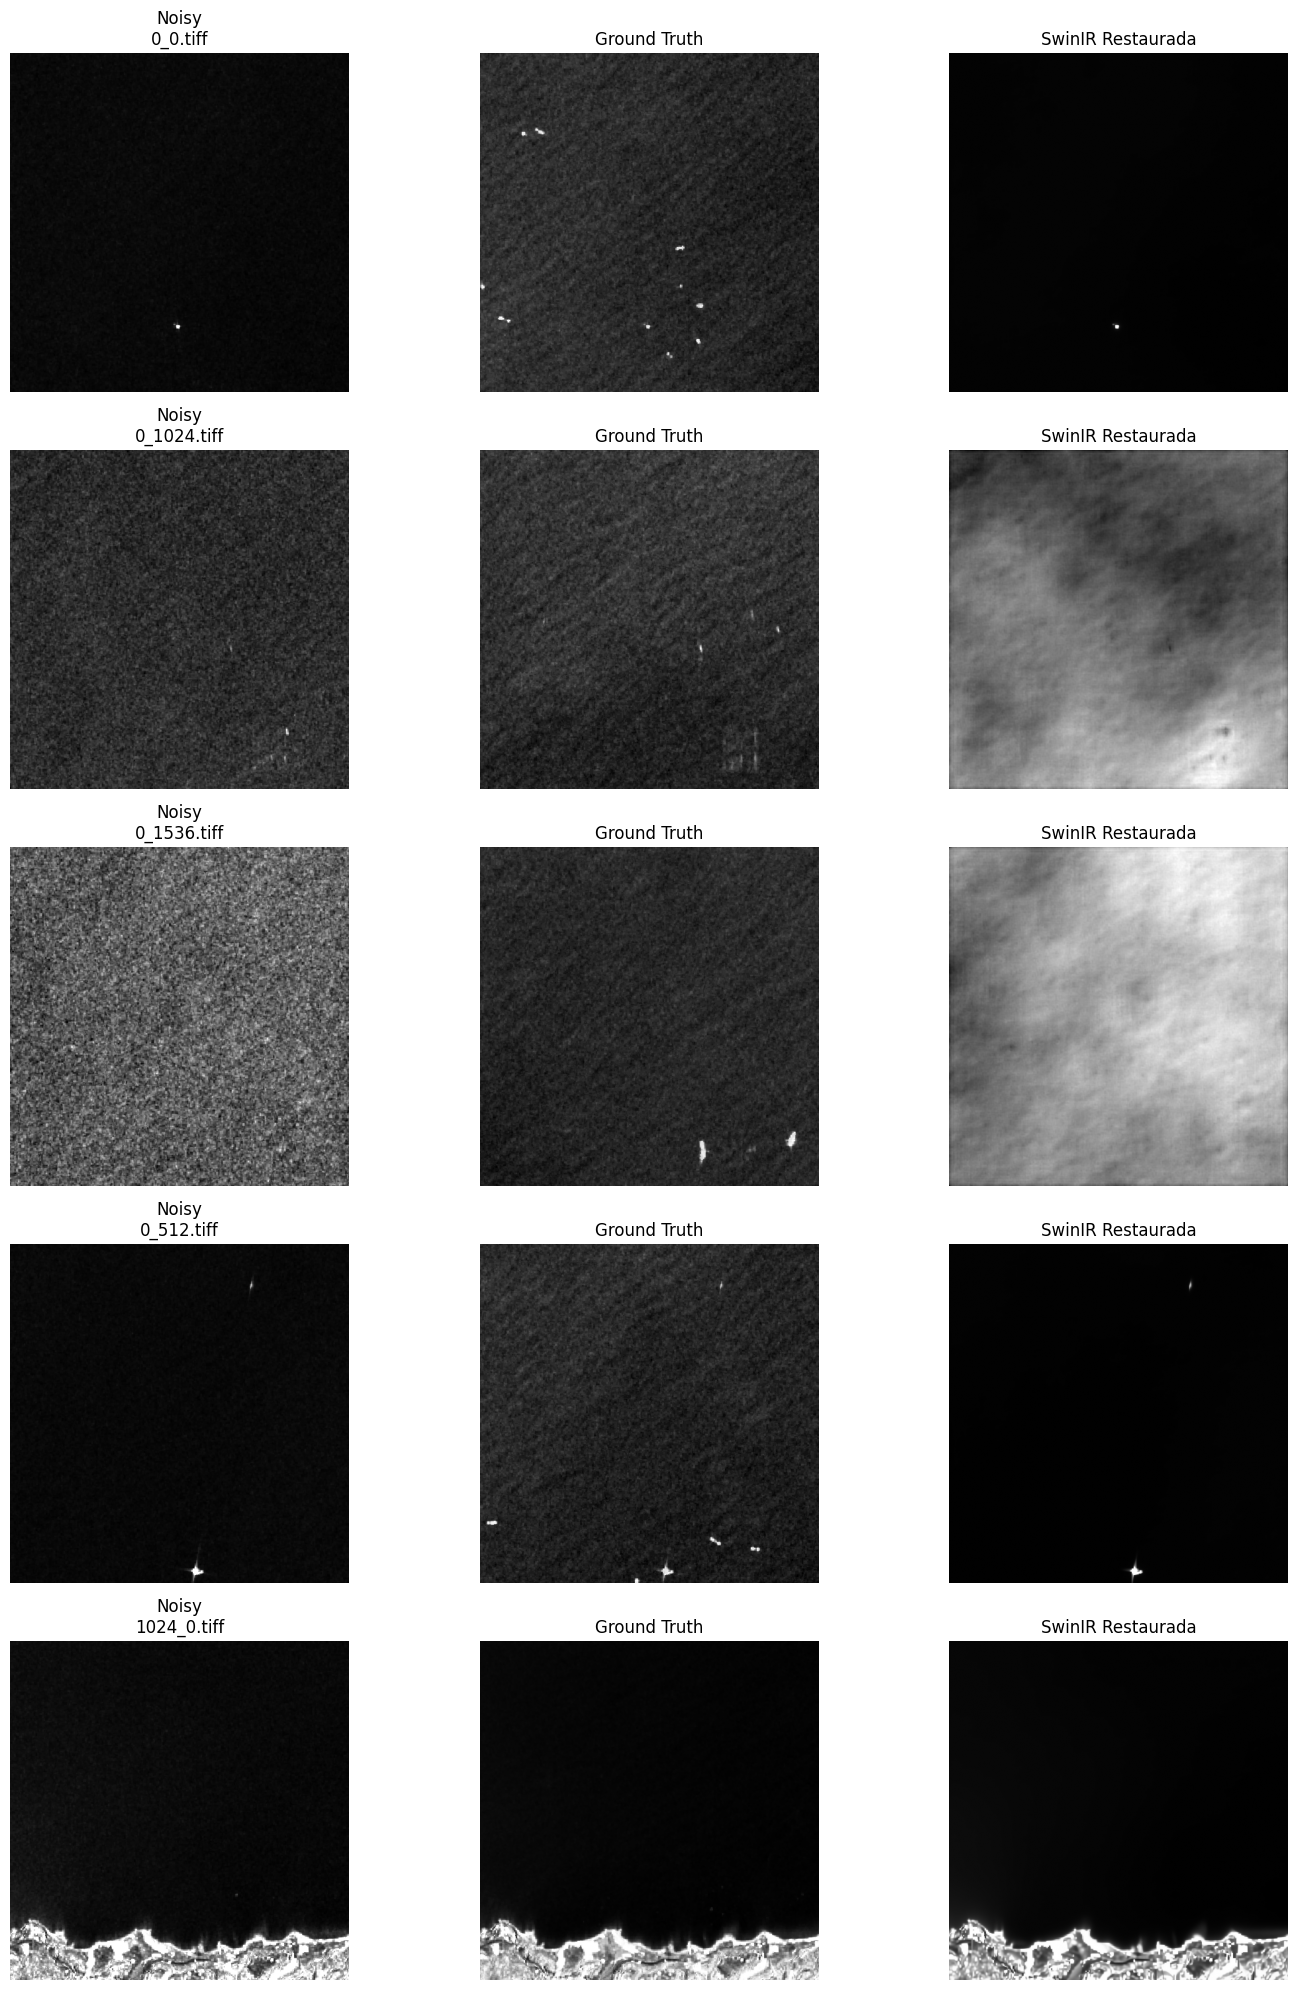

In [16]:
def mostrar_resultados_swinir(examples):
    n = len(examples)

    plt.figure(figsize=(15, 4 * n))

    for row, (filename, noisy_img, gtruth_img, restored_img) in enumerate(examples):
        plt.subplot(n, 3, row * 3 + 1)
        plt.imshow(noisy_img, cmap="gray")
        plt.title(f"Noisy\n{filename}")
        plt.axis("off")

        plt.subplot(n, 3, row * 3 + 2)
        plt.imshow(gtruth_img, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n, 3, row * 3 + 3)
        plt.imshow(restored_img, cmap="gray")
        plt.title("SwinIR Restaurada")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


mostrar_resultados_swinir(visual_examples)

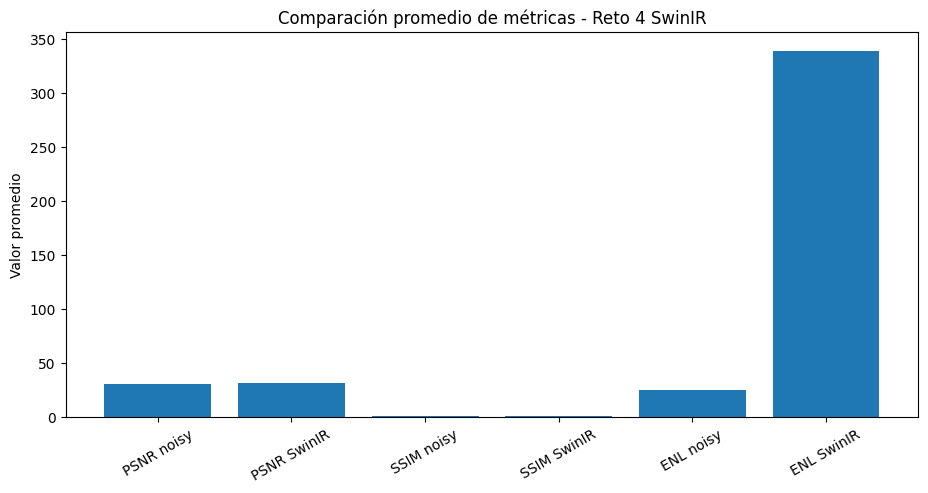

PSNR noisy: 30.5749
PSNR SwinIR: 31.4323
SSIM noisy: 0.8902
SSIM SwinIR: 0.9265
ENL noisy: 25.5769
ENL SwinIR: 339.4755


In [17]:
metric_compare = {
    "PSNR noisy": df_metrics["PSNR_noisy"].mean(),
    "PSNR SwinIR": df_metrics["PSNR_swinir"].mean(),
    "SSIM noisy": df_metrics["SSIM_noisy"].mean(),
    "SSIM SwinIR": df_metrics["SSIM_swinir"].mean(),
    "ENL noisy": df_metrics["ENL_noisy"].mean(),
    "ENL SwinIR": df_metrics["ENL_swinir"].mean()
}

plt.figure(figsize=(11, 5))
plt.bar(metric_compare.keys(), metric_compare.values())
plt.title("Comparación promedio de métricas - Reto 4 SwinIR")
plt.xticks(rotation=30)
plt.ylabel("Valor promedio")
plt.show()

for k, v in metric_compare.items():
    print(f"{k}: {v:.4f}")

In [18]:
metrics_path = os.path.join(OUTPUT_PATH, "metricas_swinir.csv")
summary_path = os.path.join(OUTPUT_PATH, "resumen_metricas_swinir.csv")

df_metrics.to_csv(metrics_path, index=False)
summary_metrics.to_csv(summary_path)

print("Métricas guardadas en:", metrics_path)
print("Resumen guardado en:", summary_path)
print("Imágenes restauradas guardadas en:", RESTORED_PATH)

Métricas guardadas en: /content/drive/MyDrive/VISION-4/RETO4/evidencias_swinir/metricas_swinir.csv
Resumen guardado en: /content/drive/MyDrive/VISION-4/RETO4/evidencias_swinir/resumen_metricas_swinir.csv
Imágenes restauradas guardadas en: /content/drive/MyDrive/VISION-4/RETO4/evidencias_swinir/restored_tiff


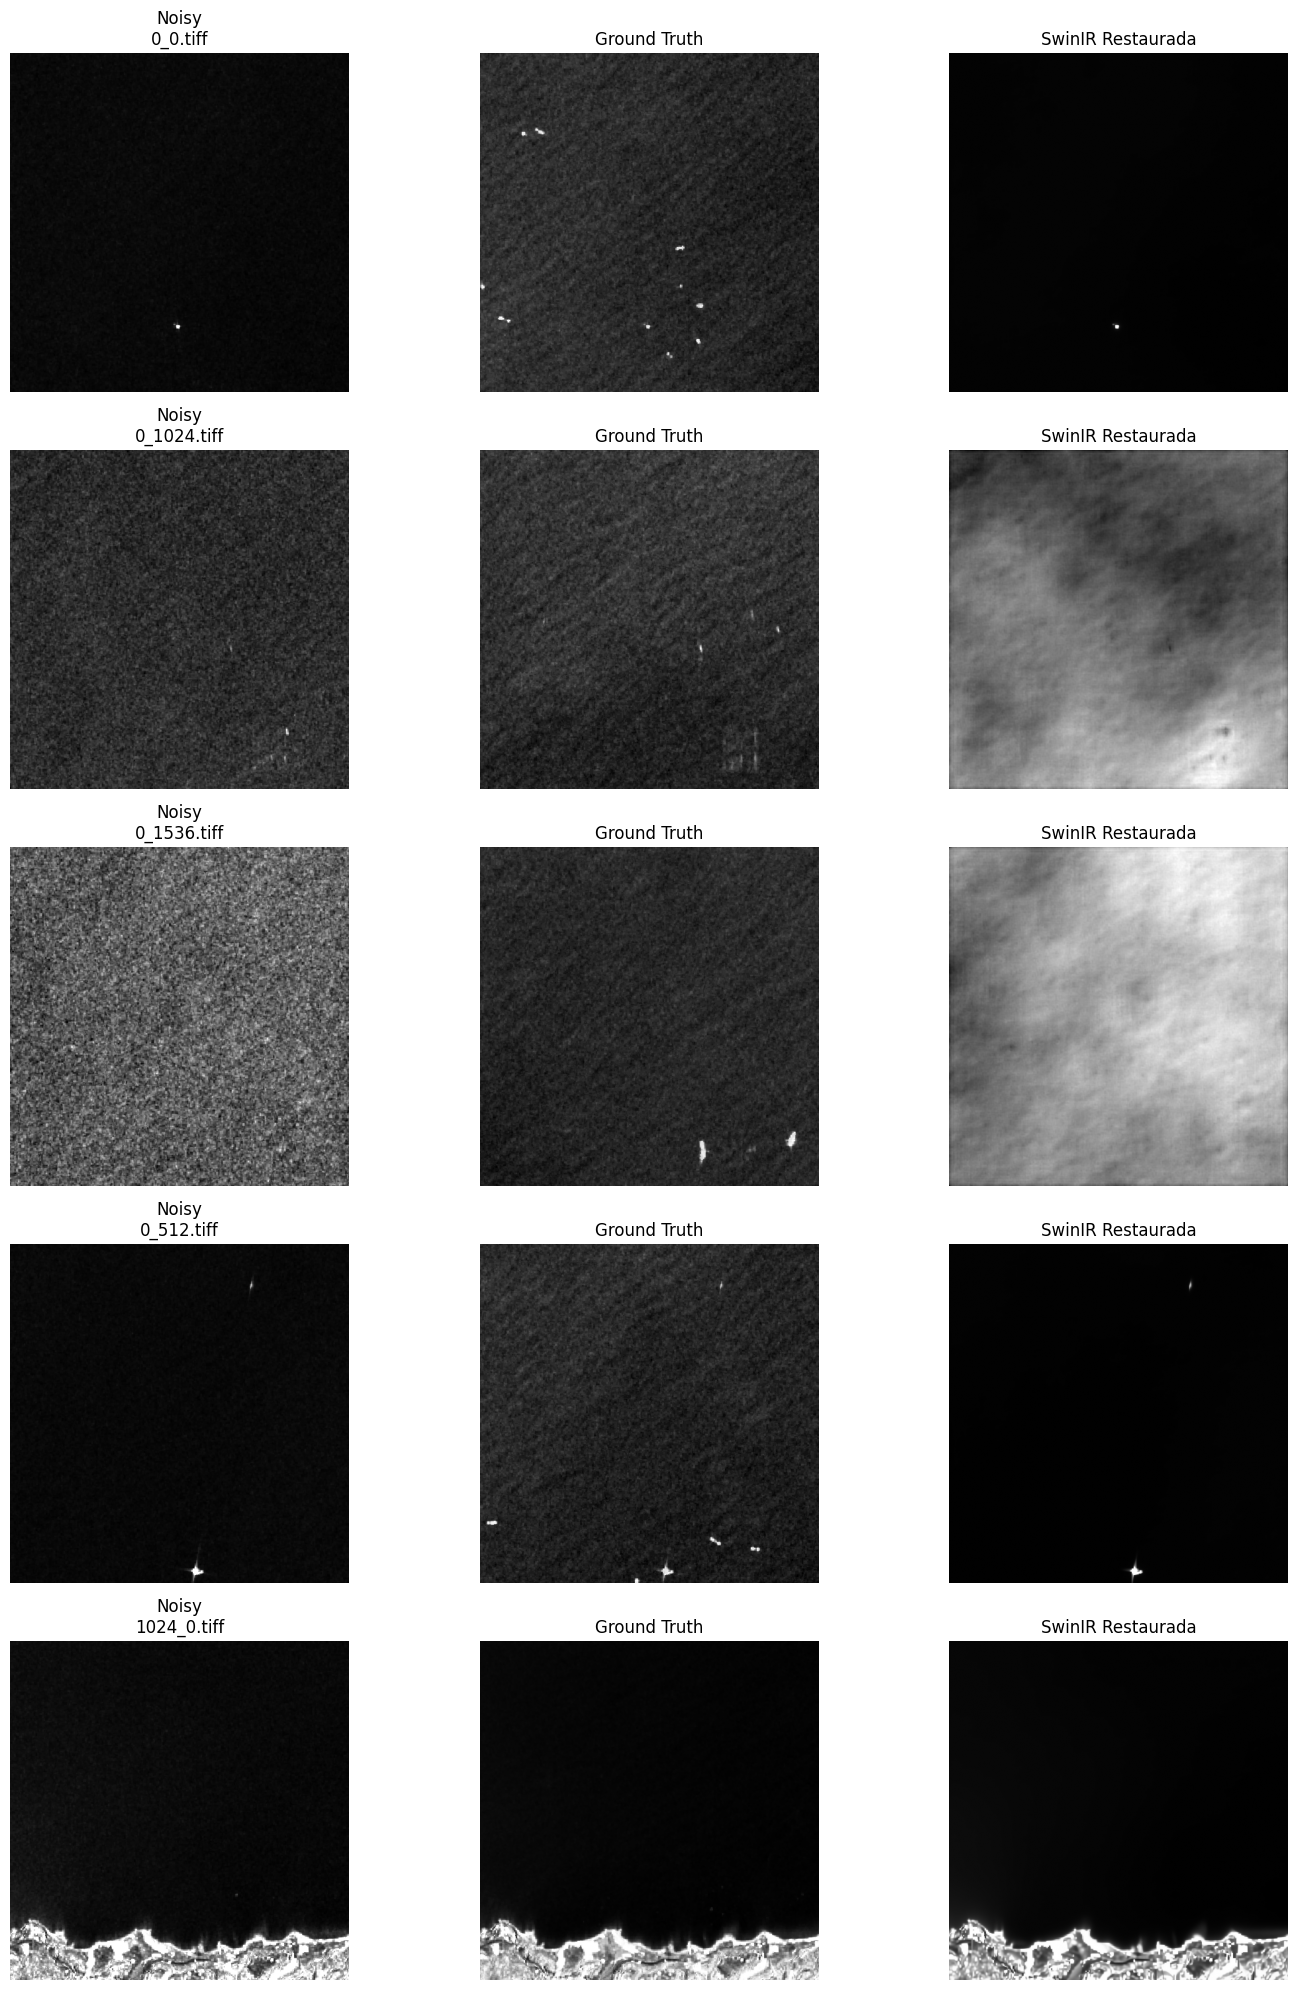

Figura guardada en: /content/drive/MyDrive/VISION-4/RETO4/evidencias_swinir/comparacion_visual_swinir.png


In [19]:
fig_path = os.path.join(OUTPUT_PATH, "comparacion_visual_swinir.png")

n = len(visual_examples)
plt.figure(figsize=(15, 4 * n))

for row, (filename, noisy_img, gtruth_img, restored_img) in enumerate(visual_examples):
    plt.subplot(n, 3, row * 3 + 1)
    plt.imshow(noisy_img, cmap="gray")
    plt.title(f"Noisy\n{filename}")
    plt.axis("off")

    plt.subplot(n, 3, row * 3 + 2)
    plt.imshow(gtruth_img, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, row * 3 + 3)
    plt.imshow(restored_img, cmap="gray")
    plt.title("SwinIR Restaurada")
    plt.axis("off")

plt.tight_layout()
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Figura guardada en:", fig_path)